In [2]:
!pip install shap

=== Setting up LightGBM (Using Pre-Logged Targets from Phase 2) ===

🚀 Training LightGBM on 5 Folds...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000978 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5014
[LightGBM] [Info] Number of data points in the train set: 27216, number of used features: 20
[LightGBM] [Info] Start training from score 10.648401


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 1 | MAE: 8512.7 MeV | RelMAD: 7.05%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5013
[LightGBM] [Info] Number of data points in the train set: 27216, number of used features: 20
[LightGBM] [Info] Start training from score 10.652745


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 2 | MAE: 8574.8 MeV | RelMAD: 7.08%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5014
[LightGBM] [Info] Number of data points in the train set: 27216, number of used features: 20
[LightGBM] [Info] Start training from score 10.649899


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 3 | MAE: 8537.2 MeV | RelMAD: 7.14%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5012
[LightGBM] [Info] Number of data points in the train set: 27216, number of used features: 20
[LightGBM] [Info] Start training from score 10.650517


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 4 | MAE: 8640.4 MeV | RelMAD: 6.81%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000737 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5012
[LightGBM] [Info] Number of data points in the train set: 27216, number of used features: 20
[LightGBM] [Info] Start training from score 10.648989
   Fold 5 | MAE: 8198.3 MeV | RelMAD: 6.85%

✅ Cross-Validation Complete!
----------------------------------------
Average MAE:    8492.7 MeV
Average RelMAD: 6.99%
----------------------------------------



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_7743/3937127652.py:86: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([true_energy_mev.min(), true_energy_mev.max()], [true_energy_mev.min(), true_energy_mev.max()], 'k--', lw=2, color='red')


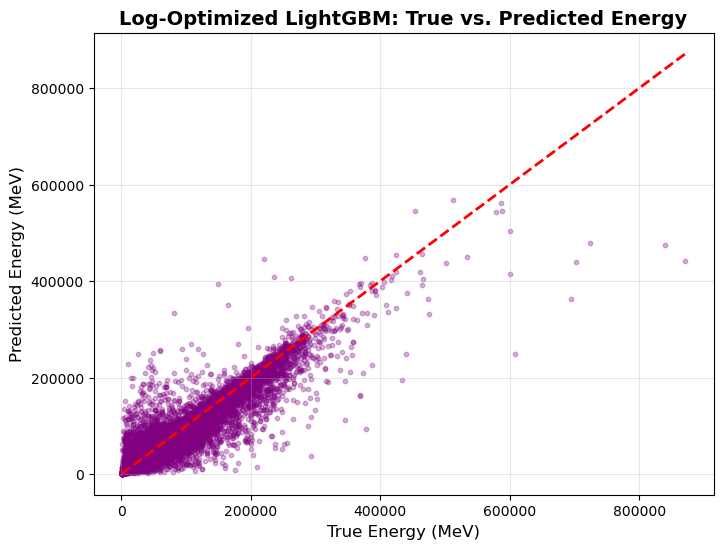

In [66]:
import pandas as pd
import numpy as np
print("=== Phase 2: Prepping Data for Regression ===\n")

# 1. Load the original dataset
print("Loading the full training dataset...")
train_df = pd.read_hdf('AppML_InitialProject_train.h5')

# 2. The Filter: Keep ONLY the real electrons
print(f"Original dataset shape: {train_df.shape}")
electrons_df = train_df[train_df['p_Truth_isElectron'] == 1].copy()
print(f"Shape after filtering for electrons: {electrons_df.shape}")

# 3. The Cleanup: Drop the Classification column
# Since every single row is now a '1', this column provides zero information 
# to a machine learning model. It is mathematically useless, so we delete it.
electrons_df = electrons_df.drop(columns=['p_Truth_isElectron'])

# 4. Define your NEW Target (y) and Features (X)
# For Regression, the answer key is the exact True Energy
y_train_reg = np.log(electrons_df['p_Truth_Energy'])

# Your input sensors (X) are everything else EXCEPT the answer key
X_train_reg = electrons_df.drop(columns=['p_Truth_Energy'])

print("\n✅ Dataset is officially prepped for Regression!")
print(f"X (Sensors) shape: {X_train_reg.shape}")
print(f"y (Target Energy) shape: {y_train_reg.shape}")

# Display a quick peek at the new Target variable to see what you are predicting
print("\nA peek at the first 5 Energy values you need to predict (in MeV):")
display(y_train_reg.head())

In [4]:
from sklearn.model_selection import train_test_split

print("=== Splitting Data: K-Fold Train vs. Locked Test Set ===\n")

# Splitting off 20% of the data to lock in the vault
X_train_kfold, X_test, y_train_kfold, y_test = train_test_split(
    X_train_reg, 
    y_train_reg, 
    test_size=0.10, 
    random_state=42 # Ensures we get the exact same split every time we run the notebook
)

print("✅ Data successfully split!")
print(f"Data for K-Fold Training & Tuning: {X_train_kfold.shape[0]} rows")
print(f"Locked Vault Data (Final Test Set):  {X_test.shape[0]} rows")

# --- 🛡️ THE SAFETY OVERRIDE 🛡️ ---
# Delete the unbroken original datasets from computer memory
# This makes it physically impossible to accidentally train on the test data later
del X_train_reg
del y_train_reg
print("\n🔒 Safety Check: Unbroken datasets deleted from memory to prevent data leakage.")

=== Splitting Data: K-Fold Train vs. Locked Test Set ===

✅ Data successfully split!
Data for K-Fold Training & Tuning: 34020 rows
Locked Vault Data (Final Test Set):  3780 rows

🔒 Safety Check: Unbroken datasets deleted from memory to prevent data leakage.


In [5]:
import numpy as np

print("=== Phase 2.1: Dropping Redundant Variables (Correlation > 0.90) ===\n")

# 1. Calculate the absolute correlation matrix on the K-Fold training data
print("Calculating correlation matrix on X_train_kfold... (This might take a minute)")
corr_matrix_reg = X_train_kfold.corr(method='pearson').abs()

# 2. Select the upper triangle of the correlation matrix
upper_triangle_reg = corr_matrix_reg.where(np.triu(np.ones(corr_matrix_reg.shape), k=1).astype(bool))

# 3. Set the threshold
threshold = 0.90

# 4. Find the features that exceed the threshold
to_drop_reg = [column for column in upper_triangle_reg.columns if any(upper_triangle_reg[column] > threshold)]

# 5. Execute the drop on BOTH the training and test sets
if len(to_drop_reg) == 0:
    print(f"\n✅ No highly correlated variables found above the {threshold} threshold.")
else:
    print(f"\n✂️ Found {len(to_drop_reg)} highly correlated column(s). Dropping them now...\n")
    
    X_train_kfold = X_train_kfold.drop(columns=to_drop_reg)
    X_test = X_test.drop(columns=to_drop_reg) # Must drop from the vault data too!
    
    print(f"✅ Drop complete!")
    print(f"New X_train_kfold shape: {X_train_kfold.shape}")
    print(f"New X_test shape:        {X_test.shape}")

=== Phase 2.1: Dropping Redundant Variables (Correlation > 0.90) ===

Calculating correlation matrix on X_train_kfold... (This might take a minute)

✂️ Found 55 highly correlated column(s). Dropping them now...

✅ Drop complete!
New X_train_kfold shape: (34020, 85)
New X_test shape:        (3780, 85)


In [13]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

print("=== Phase 2.2: Full Variable Ranking (Mutual Information) ===")
print("Calculating Mutual Information scores for ALL variables... (This will take a minute or two)\n")

# 1. Calculate the Mutual Information scores for every single feature
# (random_state=42 ensures you get the exact same scores every time you run this cell)
mi_scores = mutual_info_regression(X_train_kfold, y_train_kfold, random_state=42)

# 2. Create a DataFrame to hold the scores
mi_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'MI_Score': mi_scores
})

# 3. Sort from highest score (cleanest signal) to lowest score (most noisy)
mi_ranking_df = mi_ranking_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# 4. Display the entire ranked list
# Note: Pandas might automatically hide the middle rows if the list is too long,
# but you will clearly see the strongest variables at the top and the weakest at the bottom.
pd.set_option('display.max_rows', 150) # Forces Pandas to show all 140 rows
print("✅ All Variables Ranked by Mutual Information (Least Noisy to Most Noisy):")
display(mi_ranking_df)

# Resetting Pandas display options back to normal just in case
pd.reset_option('display.max_rows')

=== Phase 2.2: Full Variable Ranking (Mutual Information) ===
Calculating Mutual Information scores for ALL variables... (This will take a minute or two)

✅ All Variables Ranked by Mutual Information (Least Noisy to Most Noisy):


,Variable,MI_Score
0,pX_topoetcone20ptCorrection,0.795479
1,pX_topoetcone30ptCorrection,0.668954
2,pX_E7x7_Lr2,0.639672
3,p_pt_track,0.513719
4,pX_E_Lr2_HiG,0.482775
5,pX_E3x5_Lr1,0.433891
6,pX_e1152,0.426289
7,pX_barys1,0.395404
8,pX_E_Lr1_MedG,0.370103
9,pX_deltaPhi2,0.356453


In [14]:
mutual_regression = mi_ranking_df

In [15]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("=== Phase 2.3: Lasso Regression Variable Ranking ===\n")

# 1. SCALE THE DATA (Critical for Lasso)
print("Scaling the data so Lasso plays fair...")
scaler = StandardScaler()
X_train_kfold_scaled = scaler.fit_transform(X_train_kfold)

# 2. INITIALIZE AND TRAIN LASSO
# 'alpha' is the penalty strength (λ). 0.1 is a good starting point. 
# If it drops too many variables to zero, make alpha smaller (e.g., 0.01).
# If it keeps too many variables, make alpha bigger (e.g., 1.0).
print("Training the Lasso model... (This is usually very fast)")
lasso_model = Lasso(alpha=0.5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_kfold_scaled, y_train_kfold)

# 3. EXTRACT AND RANK THE WEIGHTS
# We take the absolute value because a strong negative correlation (-500) 
# is just as useful for predicting energy as a strong positive one (+500).
lasso_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Raw_Weight': lasso_model.coef_,
    'Importance': np.abs(lasso_model.coef_)
})

# Sort from most important (largest absolute weight) to least important
lasso_ranking_df = lasso_ranking_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 4. DISPLAY THE RESULTS
# Let's see how many variables Lasso decided to completely execute (Weight = 0)
zero_weight_count = (lasso_ranking_df['Importance'] == 0).sum()
print(f"\n✅ Lasso finished! It forced exactly {zero_weight_count} variables to 0.0.")

pd.set_option('display.max_rows', 150)
print("\n🏆 All Variables Ranked by Lasso Importance (Top = Best, Bottom = Dropped):")
display(lasso_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.3: Lasso Regression Variable Ranking ===

Scaling the data so Lasso plays fair...
Training the Lasso model... (This is usually very fast)

✅ Lasso finished! It forced exactly 82 variables to 0.0.

🏆 All Variables Ranked by Lasso Importance (Top = Best, Bottom = Dropped):


,Variable,Raw_Weight,Importance
0,pX_deltaPhi2,0.109597,0.109597
1,p_ptcone20,-0.048912,0.048912
2,pX_MultiLepton,0.048297,0.048297
3,pX_emins1,-0.000000,0.000000
4,pX_nCells_Lr0_HiG,-0.000000,0.000000
5,pX_maxEcell_y,0.000000,0.000000
6,pX_maxEcell_x,0.000000,0.000000
7,pX_maxEcell_time,0.000000,0.000000
8,pX_maxEcell_gain,0.000000,0.000000
9,pX_f3core,-0.000000,0.000000


In [20]:
lasso = lasso_ranking_df

In [21]:
compare_top_n_dfs(lasso, mutual_regression, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 3 in Table 1: 'pX_MultiLepton' is missing from Table 2's top 20.
 ⚠️ Rank 4 in Table 1: 'pX_emins1' is missing from Table 2's top 20.
 ⚠️ Rank 5 in Table 1: 'pX_nCells_Lr0_HiG' is missing from Table 2's top 20.
 ⚠️ Rank 6 in Table 1: 'pX_maxEcell_y' is missing from Table 2's top 20.
 ⚠️ Rank 7 in Table 1: 'pX_maxEcell_x' is missing from Table 2's top 20.
 ⚠️ Rank 8 in Table 1: 'pX_maxEcell_time' is missing from Table 2's top 20.
 ⚠️ Rank 9 in Table 1: 'pX_maxEcell_gain' is missing from Table 2's top 20.
 ⚠️ Rank 10 in Table 1: 'pX_f3core' is missing from Table 2's top 20.
 ⚠️ Rank 11 in Table 1: 'pX_f1core' is missing from Table 2's top 20.
 ⚠️ Rank 12 in Table 1: 'averageInteractionsPerCrossing' is missing from Table 2's top 20.
 ⚠️ Rank 13 in Table 1: 'pX_e2ts1' is missing from Table 2's top 20.
 ⚠️ Rank 14 in Table 1: 'pX_nCells_Lr1_HiG' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'pX_deltaPhiRescaled1' is mis

In [22]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 2.4: Tree-Based Feature Importance (Random Forest) ===\n")

# 1. Initialize the Random Forest
# n_estimators=100 is plenty for a rough feature ranking.
print("Training the Random Forest... (This might take a few minutes)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on your raw, unscaled K-Fold data
rf_model.fit(X_train_kfold, y_train_kfold)

# 3. Extract the built-in feature importances
tree_importances = rf_model.feature_importances_

# 4. Create a DataFrame to hold and rank the scores
tree_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Importance_Weight': tree_importances
})

# 5. Sort from highest weight to lowest weight
tree_ranking_df = tree_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 6. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Random Forest Importance (Highest to Lowest):")
display(tree_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.4: Tree-Based Feature Importance (Random Forest) ===

Training the Random Forest... (This might take a few minutes)
✅ Variables Ranked by Random Forest Importance (Highest to Lowest):


,Variable,Importance_Weight
0,p_pt_track,2.419967e-01
1,p_etcone20,1.612719e-01
2,p_ptcone20,1.148953e-01
3,pX_E_Lr1_MedG,1.022228e-01
4,pX_deltaPhi2,9.764549e-02
5,pX_E7x7_Lr2,4.285130e-02
6,pX_topoetcone20ptCorrection,3.296413e-02
7,pX_E3x5_Lr1,1.994392e-02
8,pX_E_Lr0_HiG,1.838269e-02
9,pX_E_Lr2_MedG,1.689960e-02


In [24]:
tree_100 = tree_ranking_df

In [25]:
compare_top_n_dfs(tree_100, mutual_regression, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 14 in Table 1: 'pX_MultiLepton' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'p_deltaPhiRescaled2' is missing from Table 2's top 20.
 ⚠️ Rank 16 in Table 1: 'pX_r33over37allcalo' is missing from Table 2's top 20.
 ⚠️ Rank 17 in Table 1: 'p_numberOfTRTXenonHits' is missing from Table 2's top 20.
 ⚠️ Rank 19 in Table 1: 'p_d0' is missing from Table 2's top 20.

=== Checking Top 20 of Table 2 against Table 1 ===
 ⚠️ Rank 8 in Table 2: 'pX_barys1' is missing from Table 1's top 20.
 ⚠️ Rank 13 in Table 2: 'pX_wtots1' is missing from Table 1's top 20.
 ⚠️ Rank 16 in Table 2: 'p_Eratio' is missing from Table 1's top 20.
 ⚠️ Rank 18 in Table 2: 'pX_core57cellsEnergyCorrection' is missing from Table 1's top 20.
 ⚠️ Rank 20 in Table 2: 'p_Rphi' is missing from Table 1's top 20.


In [26]:
compare_top_n_dfs(tree_100, lasso, 20) 


=== Checking Top 20 of Table 1 against Table 2 ===
 ⚠️ Rank 1 in Table 1: 'p_pt_track' is missing from Table 2's top 20.
 ⚠️ Rank 2 in Table 1: 'p_etcone20' is missing from Table 2's top 20.
 ⚠️ Rank 4 in Table 1: 'pX_E_Lr1_MedG' is missing from Table 2's top 20.
 ⚠️ Rank 6 in Table 1: 'pX_E7x7_Lr2' is missing from Table 2's top 20.
 ⚠️ Rank 7 in Table 1: 'pX_topoetcone20ptCorrection' is missing from Table 2's top 20.
 ⚠️ Rank 8 in Table 1: 'pX_E3x5_Lr1' is missing from Table 2's top 20.
 ⚠️ Rank 9 in Table 1: 'pX_E_Lr0_HiG' is missing from Table 2's top 20.
 ⚠️ Rank 10 in Table 1: 'pX_E_Lr2_MedG' is missing from Table 2's top 20.
 ⚠️ Rank 11 in Table 1: 'p_sigmad0' is missing from Table 2's top 20.
 ⚠️ Rank 13 in Table 1: 'pX_E_Lr2_HiG' is missing from Table 2's top 20.
 ⚠️ Rank 15 in Table 1: 'p_deltaPhiRescaled2' is missing from Table 2's top 20.
 ⚠️ Rank 16 in Table 1: 'pX_r33over37allcalo' is missing from Table 2's top 20.
 ⚠️ Rank 17 in Table 1: 'p_numberOfTRTXenonHits' is missin

In [27]:
import pandas as pd

def compare_top_n_dfs(df1, df2, n, col_name='Variable'):
    """
    Takes two Pandas DataFrames, extracts the top 'n' variable names, 
    and checks for missing values between the two lists, completely ignoring weights.
    """
    
    # 1. Safety Check: Make sure the column actually exists in both tables
    if col_name not in df1.columns or col_name not in df2.columns:
        print(f"❌ Error: Could not find the column '{col_name}'.")
        print(f"Columns in Table 1: {list(df1.columns)}")
        print(f"Columns in Table 2: {list(df2.columns)}")
        return

    # 2. Extract strictly the top 'n' names from both DataFrames into simple lists
    # .head(n) grabs the top n rows, .tolist() converts them to plain text lists
    list1 = df1[col_name].head(n).tolist()
    list2 = df2[col_name].head(n).tolist()

    # 3. Compare Table 1 against Table 2
    print(f"=== Checking Top {n} of Table 1 against Table 2 ===")
    missing_from_df2 = False
    
    for i, val in enumerate(list1):
        if val not in list2:
            print(f" ⚠️ Rank {i + 1} in Table 1: '{val}' is missing from Table 2's top {n}.")
            missing_from_df2 = True
            
    if not missing_from_df2:
        print(f" ✅ All top {n} variables from Table 1 are present in Table 2!")

    # 4. Compare Table 2 against Table 1
    print(f"\n=== Checking Top {n} of Table 2 against Table 1 ===")
    missing_from_df1 = False
    
    for i, val in enumerate(list2):
        if val not in list1:
            print(f" ⚠️ Rank {i + 1} in Table 2: '{val}' is missing from Table 1's top {n}.")
            missing_from_df1 = True
            
    if not missing_from_df1:
        print(f" ✅ All top {n} variables from Table 2 are present in Table 1!")

In [28]:
from sklearn.inspection import permutation_importance
import pandas as pd

print("=== Phase 2.5: Permutation Importance Ranking ===\n")
print("Sabotaging columns one by one to see which ones break the model...")
print("⏳ Grab a coffee, this might take a few minutes!\n")

# 1. Run the Permutation algorithm
# n_repeats=5 means it scrambles each column 5 different times to get a reliable average score.
# n_jobs=-1 forces your Mac to use all available CPU cores to speed this up.
perm_results = permutation_importance(
    rf_model, 
    X_train_kfold, 
    y_train_kfold, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_absolute_error' # We measure the damage using Mean Absolute Error
)

# 2. Extract the results into a clean DataFrame
# importances_mean contains the average drop in accuracy when that column was scrambled
perm_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Importance_Drop': perm_results.importances_mean,
    'Standard_Deviation': perm_results.importances_std # Shows how much the score varied across the 5 shuffles
})

# 3. Sort from most devastating (highest drop) to least
perm_ranking_df = perm_ranking_df.sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

# 4. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):")
display(perm_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.5: Permutation Importance Ranking ===

Sabotaging columns one by one to see which ones break the model...
⏳ Grab a coffee, this might take a few minutes!



/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):


,Variable,Importance_Drop,Standard_Deviation
0,p_pt_track,1.585745e-01,1.267183e-03
1,pX_E7x7_Lr2,1.435565e-01,5.151448e-04
2,p_etcone20,9.256605e-02,7.942905e-04
3,pX_topoetcone20ptCorrection,9.015933e-02,7.021743e-04
4,pX_E3x5_Lr1,8.388508e-02,6.484633e-04
5,pX_E_Lr0_HiG,7.614721e-02,3.534825e-04
6,pX_E_Lr1_MedG,7.284106e-02,7.260326e-04
7,pX_deltaPhi2,7.024540e-02,1.185974e-04
8,p_ptcone20,5.941442e-02,6.026274e-04
9,p_sigmad0,4.357627e-02,5.628249e-04


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [29]:
perm_5 = perm_ranking_df

=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===

Sampling data to prevent memory overload...
Training lightweight Random Forest... (Should take < 10 seconds)
Calculating exact SHAP values... (Should take ~30 seconds ⏳)

✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):


,Variable,Mean_SHAP_Impact_MeV
0,p_etcone20,0.204974
1,p_ptcone20,0.157056
2,p_pt_track,0.150971
3,pX_E_Lr1_MedG,0.133721
4,pX_E7x7_Lr2,0.125297
5,pX_deltaPhi2,0.100122
6,pX_E3x5_Lr1,0.080643
7,pX_topoetcone20ptCorrection,0.073549
8,pX_E_Lr0_HiG,0.061949
9,p_sigmad0,0.038952



📊 Generating the visual SHAP Summary Plot...


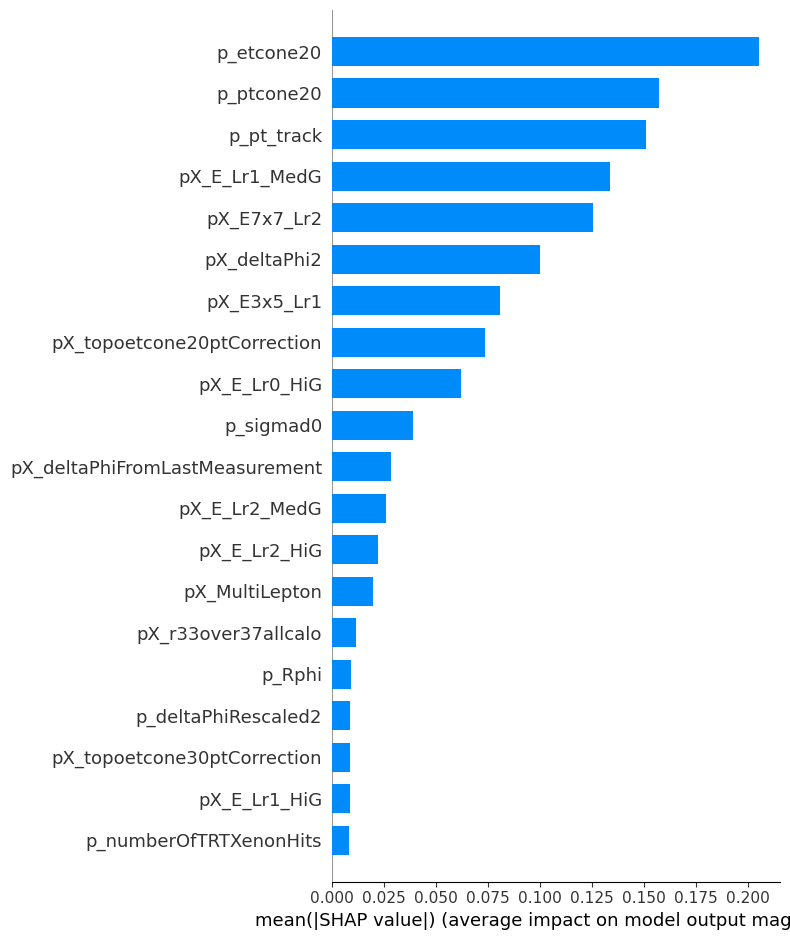

In [30]:
from sklearn.ensemble import RandomForestRegressor
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===\n")

# 1. Take a subset of data to train the forest lightning fast
print("Sampling data to prevent memory overload...")
X_train_fast = X_train_kfold.sample(n=10000, random_state=42)
y_train_fast = y_train_kfold.loc[X_train_fast.index]

# 2. Train a restricted, lightweight Random Forest 
print("Training lightweight Random Forest... (Should take < 10 seconds)")
# max_depth=10 stops the trees from growing infinitely deep and eating your RAM
rf_model_fast = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=1)
rf_model_fast.fit(X_train_fast, y_train_fast)

# 3. Take a smaller sample for the SHAP explainer
print("Calculating exact SHAP values... (Should take ~30 seconds ⏳)")
X_shap_sample = X_train_fast.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf_model_fast)
shap_values = explainer.shap_values(X_shap_sample)

# 4. Rank and Display
shap_importance = np.abs(shap_values).mean(axis=0)
shap_ranking_df = pd.DataFrame({
    'Variable': X_train_kfold.columns,
    'Mean_SHAP_Impact_MeV': shap_importance
})
shap_ranking_df = shap_ranking_df.sort_values(by='Mean_SHAP_Impact_MeV', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 150)
print("\n✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):")
display(shap_ranking_df.head(40)) # Only displaying the top 40 to keep it clean
pd.reset_option('display.max_rows')

# 5. The Beautiful Visual
print("\n📊 Generating the visual SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", max_display=20)

In [31]:
shap_5000 = shap_ranking_df

In [32]:
set_mutual_reg = set(mutual_regression.head(20)['Variable'])
set_lasso = set(lasso.head(20)['Variable'])
set_tree = set(tree_100.head(20)['Variable'])
set_perm = set(perm_5.head(20)['Variable'])
set_shap_5000 = set(shap_5000.head(20)['Variable'])

union_1_set = (((set_mutual_reg.union(set_lasso)).union(set_tree)).union(set_perm)).union(set_shap_5000)
print(union_1_set)
print(len(union_1_set))

{'pX_E3x5_Lr1', 'pX_f1core', 'pX_deltaPhi3', 'p_numberOfTRTXenonHits', 'pX_e1152', 'pX_maxEcell_x', 'pX_deltaEta1', 'p_sigmad0', 'pX_barys1', 'pX_nCells_Lr0_HiG', 'pX_maxEcell_time', 'p_deltaPhiRescaled2', 'pX_topoetcone20ptCorrection', 'pX_core57cellsEnergyCorrection', 'pX_E7x7_Lr2', 'averageInteractionsPerCrossing', 'p_Eratio', 'pX_E_Lr2_MedG', 'pX_deltaPhiRescaled1', 'pX_E_Lr0_HiG', 'p_etcone20', 'pX_deltaEta2', 'pX_f3core', 'pX_r33over37allcalo', 'pX_topoetcone30ptCorrection', 'pX_E_Lr1_MedG', 'pX_nCells_Lr1_HiG', 'p_d0', 'pX_MultiLepton', 'pX_deltaEta3', 'pX_E_Lr1_HiG', 'p_Rphi', 'pX_emins1', 'pX_maxEcell_gain', 'pX_E_Lr2_HiG', 'pX_maxEcell_y', 'p_pt_track', 'pX_wtots1', 'pX_e2ts1', 'p_ptcone20', 'pX_deltaPhiFromLastMeasurement', 'pX_deltaPhi2'}
42


In [33]:
final_features = list(union_1_set)
print(final_features)

['pX_E3x5_Lr1', 'pX_f1core', 'pX_deltaPhi3', 'p_numberOfTRTXenonHits', 'pX_e1152', 'pX_maxEcell_x', 'pX_deltaEta1', 'p_sigmad0', 'pX_barys1', 'pX_nCells_Lr0_HiG', 'pX_maxEcell_time', 'p_deltaPhiRescaled2', 'pX_topoetcone20ptCorrection', 'pX_core57cellsEnergyCorrection', 'pX_E7x7_Lr2', 'averageInteractionsPerCrossing', 'p_Eratio', 'pX_E_Lr2_MedG', 'pX_deltaPhiRescaled1', 'pX_E_Lr0_HiG', 'p_etcone20', 'pX_deltaEta2', 'pX_f3core', 'pX_r33over37allcalo', 'pX_topoetcone30ptCorrection', 'pX_E_Lr1_MedG', 'pX_nCells_Lr1_HiG', 'p_d0', 'pX_MultiLepton', 'pX_deltaEta3', 'pX_E_Lr1_HiG', 'p_Rphi', 'pX_emins1', 'pX_maxEcell_gain', 'pX_E_Lr2_HiG', 'pX_maxEcell_y', 'p_pt_track', 'pX_wtots1', 'pX_e2ts1', 'p_ptcone20', 'pX_deltaPhiFromLastMeasurement', 'pX_deltaPhi2']


In [34]:
# Safety Check: Let's make absolutely sure all 40 columns exist in your dataset
missing_cols = [col for col in final_features if col not in X_train_kfold.columns]
if missing_cols:
    print(f"⚠️ WARNING: The following columns were not found in your data: {missing_cols}")
else:
    # 2. Slice the datasets
    # We create new variables so we don't accidentally destroy our K-Fold data
    X_train_final = X_train_kfold[final_features].copy()
    X_test_final = X_test[final_features].copy() # You MUST do the exact same to the vault data!
    
    print("✅ Datasets successfully filtered!")
    print(f"Training Data Shape: {X_train_final.shape}")
    print(f"Test Data Shape:     {X_test_final.shape}")

✅ Datasets successfully filtered!
Training Data Shape: (34020, 42)
Test Data Shape:     (3780, 42)


In [35]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 4: Recursive Feature Elimination (RFE) Ranking ===\n")

# 1. Initialize the lightweight judge
# n_jobs=-1 lets it use all CPU cores to speed up the 40 training loops
print("Setting up the estimator...")
estimator = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# 2. Configure the RFE algorithm
# n_features_to_select=1 forces it to fight to the death (leaving 1 survivor)
# step=1 means it is only allowed to eliminate 1 variable per round
print("Commencing the RFE tournament... (This will take a few minutes ⏳)")
rfe = RFE(estimator=estimator, n_features_to_select=1, step=1)

# 3. Fit the RFE on your strictly filtered 40-variable dataset
rfe.fit(X_train_final, y_train_kfold)

# 4. Extract the rankings
# rfe.ranking_ outputs an array where '1' is the final survivor (the best), 
# and '40' is the first one that was eliminated (the worst).
rfe_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'RFE_Rank': rfe.ranking_
})

# 5. Sort the dataframe from Rank 1 (Best) to Rank 40 (Worst)
rfe_ranking_df = rfe_ranking_df.sort_values(by='RFE_Rank', ascending=True).reset_index(drop=True)

# 6. Display the final ranked list
pd.set_option('display.max_rows', 50)
print("\n✅ All 40 Variables Ranked by RFE (1 = Best, 40 = First Eliminated):")
display(rfe_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 4: Recursive Feature Elimination (RFE) Ranking ===

Setting up the estimator...
Commencing the RFE tournament... (This will take a few minutes ⏳)

✅ All 40 Variables Ranked by RFE (1 = Best, 40 = First Eliminated):


,Variable,RFE_Rank
0,p_pt_track,1
1,p_etcone20,2
2,pX_E_Lr1_MedG,3
3,pX_deltaPhi2,4
4,p_ptcone20,5
5,pX_E7x7_Lr2,6
6,pX_topoetcone20ptCorrection,7
7,pX_E3x5_Lr1,8
8,pX_E_Lr0_HiG,9
9,p_sigmad0,10


In [36]:
recursive_elimination = rfe_ranking_df

In [37]:
recursive_elimination_15 = rfe_ranking_df

In [38]:
compare_top_n_dfs(recursive_elimination, recursive_elimination_15, 20) 

=== Checking Top 20 of Table 1 against Table 2 ===
 ✅ All top 20 variables from Table 1 are present in Table 2!

=== Checking Top 20 of Table 2 against Table 1 ===
 ✅ All top 20 variables from Table 2 are present in Table 1!


=== Phase 4 (Upgraded): RFECV - Finding the Perfect Feature Count ===

Commencing 5-Fold RFECV... (This will train 200 models. Please wait ⏳)

✅ RFECV Complete!
🏆 The mathematically optimal number of features is: 32 out of 40


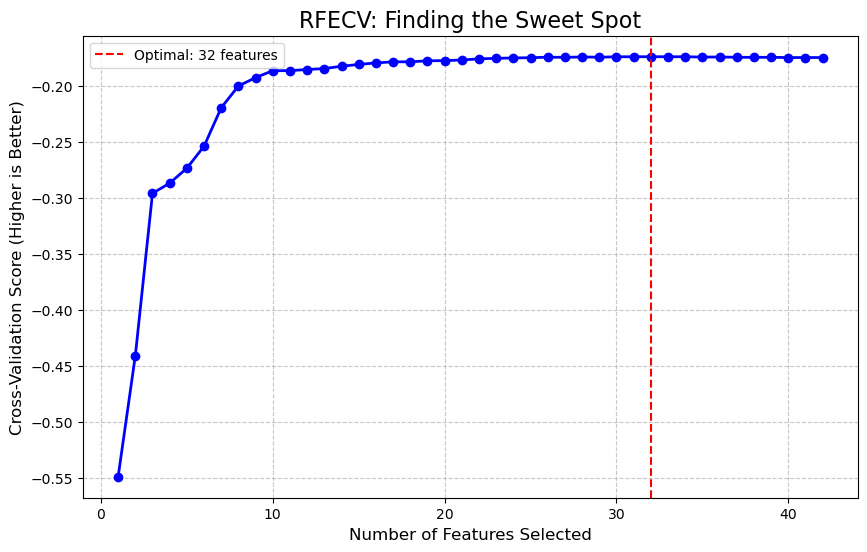


The Surviving Features:
['pX_E3x5_Lr1', 'pX_f1core', 'p_numberOfTRTXenonHits', 'pX_e1152', 'pX_deltaEta1', 'p_sigmad0', 'pX_barys1', 'pX_nCells_Lr0_HiG', 'p_deltaPhiRescaled2', 'pX_topoetcone20ptCorrection', 'pX_core57cellsEnergyCorrection', 'pX_E7x7_Lr2', 'p_Eratio', 'pX_E_Lr2_MedG', 'pX_deltaPhiRescaled1', 'pX_E_Lr0_HiG', 'p_etcone20', 'pX_deltaEta2', 'pX_r33over37allcalo', 'pX_topoetcone30ptCorrection', 'pX_E_Lr1_MedG', 'p_d0', 'pX_MultiLepton', 'pX_E_Lr1_HiG', 'p_Rphi', 'pX_E_Lr2_HiG', 'p_pt_track', 'pX_wtots1', 'pX_e2ts1', 'p_ptcone20', 'pX_deltaPhiFromLastMeasurement', 'pX_deltaPhi2']


In [39]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

print("=== Phase 4 (Upgraded): RFECV - Finding the Perfect Feature Count ===\n")

# 1. Initialize the lightweight estimator
estimator = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# 2. Configure RFECV
# cv=5 tells it to use 5-Fold Cross Validation for every single step
# scoring='neg_mean_absolute_error' ensures it optimizes for your specific metric
print("Commencing 5-Fold RFECV... (This will train 200 models. Please wait ⏳)")
rfecv = RFECV(estimator=estimator, step=1, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

# 3. Fit on the 40-variable dataset
rfecv.fit(X_train_final, y_train_kfold)

# 4. The Grand Reveal
optimal_features = rfecv.n_features_
print(f"\n✅ RFECV Complete!")
print(f"🏆 The mathematically optimal number of features is: {optimal_features} out of 40")

# 5. Plot the Cross-Validation Error Curve
plt.figure(figsize=(10, 6))
plt.title("RFECV: Finding the Sweet Spot", fontsize=16)
plt.xlabel("Number of Features Selected", fontsize=12)
plt.ylabel("Cross-Validation Score (Higher is Better)", fontsize=12)

# Plotting the curve (Note: we use the mean test score across the 5 folds)
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o', color='b', linewidth=2)
plt.axvline(x=optimal_features, color='r', linestyle='--', label=f'Optimal: {optimal_features} features')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 6. Extract the final winning columns automatically
winning_columns = X_train_final.columns[rfecv.support_]

# Lock in the final, perfect datasets
X_train_perfect = X_train_final[winning_columns]
X_test_perfect = X_test_final[winning_columns]

print("\nThe Surviving Features:")
print(winning_columns.tolist())

In [40]:
import pandas as pd

print("=== Final Ranking: The Top 20 MVPs ===\n")

# 1. Extract the internal weights from the final winning RFECV model
# rfecv.estimator_ is the Random Forest trained ONLY on the winning columns
winning_weights = rfecv.estimator_.feature_importances_

# 2. Create the DataFrame matching the surviving columns to their weights
final_ranking_df = pd.DataFrame({
    'Variable': winning_columns,
    'Importance_Weight': winning_weights
})

# 3. Sort from highest weight (the absolute best) to lowest
final_ranking_df = final_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 4. Extract just the Top 20
top_20_final_df = final_ranking_df.head(20)

# 5. Display the results
print("🏆 The Absolute Best 20 Variables (Ranked by Model Weight):")
display(top_20_final_df)

# 6. Save them to a hardcoded list for your final pipeline
top_20_features_list = top_20_final_df['Variable'].tolist()
print("\n✅ Your Top 20 Locked-In List:")
print(top_20_features_list)

=== Final Ranking: The Top 20 MVPs ===

🏆 The Absolute Best 20 Variables (Ranked by Model Weight):


,Variable,Importance_Weight
0,p_pt_track,0.302770
1,p_etcone20,0.144530
2,pX_E_Lr1_MedG,0.115400
3,p_ptcone20,0.108476
4,pX_deltaPhi2,0.094508
5,pX_topoetcone20ptCorrection,0.037457
6,pX_E7x7_Lr2,0.033975
7,pX_E3x5_Lr1,0.021872
8,pX_E_Lr2_MedG,0.018486
9,pX_E_Lr0_HiG,0.018143



✅ Your Top 20 Locked-In List:
['p_pt_track', 'p_etcone20', 'pX_E_Lr1_MedG', 'p_ptcone20', 'pX_deltaPhi2', 'pX_topoetcone20ptCorrection', 'pX_E7x7_Lr2', 'pX_E3x5_Lr1', 'pX_E_Lr2_MedG', 'pX_E_Lr0_HiG', 'p_sigmad0', 'pX_deltaPhiFromLastMeasurement', 'pX_E_Lr2_HiG', 'pX_MultiLepton', 'pX_r33over37allcalo', 'pX_topoetcone30ptCorrection', 'p_numberOfTRTXenonHits', 'p_deltaPhiRescaled2', 'p_d0', 'pX_e1152']


In [41]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("=== Phase 5: Forward Selection Draft ===\n")

# 1. Initialize the same lightweight judge so the comparison is fair
estimator = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)

# 2. Configure Forward Selection
# direction='forward' tells it to start at 0 and add variables
print("Drafting the ultimate 20-variable team from scratch... (Please wait ⏳)")
sfs = SequentialFeatureSelector(
    estimator, 
    n_features_to_select=20, 
    direction='forward', 
    cv=5, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# 3. Fit the Forward Selector on your 40-variable dataset
sfs.fit(X_train_final, y_train_kfold)

# 4. Extract the winning drafted team
# sfs.get_support() returns True for the variables that made the cut
forward_winners = X_train_final.columns[sfs.get_support()].tolist()

print(f"\n✅ Forward Selection Complete!")
print("🏆 The Top 20 Drafted Variables:")
for var in forward_winners:
    print(f" - {var}")

=== Phase 5: Forward Selection Draft ===

Drafting the ultimate 20-variable team from scratch... (Please wait ⏳)

✅ Forward Selection Complete!
🏆 The Top 20 Drafted Variables:
 - pX_maxEcell_x
 - pX_deltaEta1
 - p_sigmad0
 - pX_barys1
 - pX_maxEcell_time
 - p_deltaPhiRescaled2
 - pX_core57cellsEnergyCorrection
 - p_Eratio
 - p_etcone20
 - pX_deltaEta2
 - pX_f3core
 - pX_topoetcone30ptCorrection
 - pX_nCells_Lr1_HiG
 - p_d0
 - pX_MultiLepton
 - pX_deltaEta3
 - p_Rphi
 - pX_maxEcell_y
 - p_pt_track
 - pX_e2ts1


In [42]:
forward = forward_winners
print(forward)

['pX_maxEcell_x', 'pX_deltaEta1', 'p_sigmad0', 'pX_barys1', 'pX_maxEcell_time', 'p_deltaPhiRescaled2', 'pX_core57cellsEnergyCorrection', 'p_Eratio', 'p_etcone20', 'pX_deltaEta2', 'pX_f3core', 'pX_topoetcone30ptCorrection', 'pX_nCells_Lr1_HiG', 'p_d0', 'pX_MultiLepton', 'pX_deltaEta3', 'p_Rphi', 'pX_maxEcell_y', 'p_pt_track', 'pX_e2ts1']


In [43]:
recursive_longway_2 = top_20_final_df
print(recursive_longway_2)

                          Variable  Importance_Weight
0                       p_pt_track           0.302770
1                       p_etcone20           0.144530
2                    pX_E_Lr1_MedG           0.115400
3                       p_ptcone20           0.108476
4                     pX_deltaPhi2           0.094508
5      pX_topoetcone20ptCorrection           0.037457
6                      pX_E7x7_Lr2           0.033975
7                      pX_E3x5_Lr1           0.021872
8                    pX_E_Lr2_MedG           0.018486
9                     pX_E_Lr0_HiG           0.018143
10                       p_sigmad0           0.017191
11  pX_deltaPhiFromLastMeasurement           0.010976
12                    pX_E_Lr2_HiG           0.009953
13                  pX_MultiLepton           0.007054
14             pX_r33over37allcalo           0.005647
15     pX_topoetcone30ptCorrection           0.005102
16          p_numberOfTRTXenonHits           0.004847
17             p_deltaPhiRes

In [44]:
print("=== Cross-Referencing: The Ultimate Consensus ===\n")

# 1. Make sure we have both lists of 20 variables
# (forward_winners is already a list from the last step)
rfecv_list = recursive_longway_2['Variable'].tolist()

# 2. Convert both lists to Python "Sets" and find the intersection
# This mathematically extracts only the variables that exist in BOTH lists
ultimate_mvps = set(forward).intersection(set(rfecv_list))

# 3. Display the results
print(f"✅ The algorithms agree on {len(ultimate_mvps)} out of 20 variables!\n")

print("🏆 The Undisputed MVPs (Drafted by both algorithms):")
for var in ultimate_mvps:
    print(f" - {var}")
    
# 4. Find the disagreements (Optional but interesting)
forward_only = set(forward_winners) - set(rfecv_list)
rfecv_only = set(rfecv_list) - set(forward_winners)

print(f"\n🤔 Variables only Forward Selection liked: {list(forward_only)}")
print(f"🤔 Variables only RFECV liked: {list(rfecv_only)}")

=== Cross-Referencing: The Ultimate Consensus ===

✅ The algorithms agree on 7 out of 20 variables!

🏆 The Undisputed MVPs (Drafted by both algorithms):
 - p_sigmad0
 - p_deltaPhiRescaled2
 - p_d0
 - p_pt_track
 - p_etcone20
 - pX_MultiLepton
 - pX_topoetcone30ptCorrection

🤔 Variables only Forward Selection liked: ['pX_nCells_Lr1_HiG', 'pX_barys1', 'pX_maxEcell_time', 'pX_maxEcell_y', 'pX_core57cellsEnergyCorrection', 'pX_deltaEta3', 'pX_deltaEta2', 'p_Eratio', 'pX_e2ts1', 'pX_maxEcell_x', 'p_Rphi', 'pX_deltaEta1', 'pX_f3core']
🤔 Variables only RFECV liked: ['pX_E3x5_Lr1', 'pX_E_Lr1_MedG', 'p_numberOfTRTXenonHits', 'pX_e1152', 'pX_topoetcone20ptCorrection', 'pX_E7x7_Lr2', 'pX_E_Lr2_MedG', 'pX_E_Lr0_HiG', 'p_ptcone20', 'pX_r33over37allcalo', 'pX_deltaPhiFromLastMeasurement', 'pX_deltaPhi2', 'pX_E_Lr2_HiG']


In [45]:
top20_final = ultimate_mvps

print(ultimate_mvps)

{'p_sigmad0', 'p_deltaPhiRescaled2', 'p_d0', 'p_pt_track', 'p_etcone20', 'pX_MultiLepton', 'pX_topoetcone30ptCorrection'}


In [46]:
# 1. Initialize the Random Forest
# n_estimators=100 is plenty for a rough feature ranking.
print("Training the Random Forest... (This might take a few minutes)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on your raw, unscaled K-Fold data
rf_model.fit(X_train_final, y_train_kfold)

# 3. Extract the built-in feature importances
tree_importances = rf_model.feature_importances_

# 4. Create a DataFrame to hold and rank the scores
tree_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Importance_Weight': tree_importances
})

# 5. Sort from highest weight to lowest weight
tree_ranking_df = tree_ranking_df.sort_values(by='Importance_Weight', ascending=False).reset_index(drop=True)

# 6. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Random Forest Importance (Highest to Lowest):")
display(tree_ranking_df)
pd.reset_option('display.max_rows')

Training the Random Forest... (This might take a few minutes)
✅ Variables Ranked by Random Forest Importance (Highest to Lowest):


,Variable,Importance_Weight
0,p_pt_track,0.243363
1,p_etcone20,0.163242
2,p_ptcone20,0.116797
3,pX_E_Lr1_MedG,0.103118
4,pX_deltaPhi2,0.098669
5,pX_E7x7_Lr2,0.045058
6,pX_topoetcone20ptCorrection,0.034070
7,pX_E3x5_Lr1,0.021134
8,pX_E_Lr0_HiG,0.020017
9,p_sigmad0,0.017508


In [47]:
print("=== Phase 2.5: Permutation Importance Ranking ===\n")
print("Sabotaging columns one by one to see which ones break the model...")
print("⏳ Grab a coffee, this might take a few minutes!\n")

# 1. Run the Permutation algorithm
# n_repeats=5 means it scrambles each column 5 different times to get a reliable average score.
# n_jobs=-1 forces your Mac to use all available CPU cores to speed this up.
perm_results = permutation_importance(
    rf_model, 
    X_train_final, 
    y_train_kfold, 
    n_repeats=5, 
    random_state=42, 
    n_jobs=-1,
    scoring='neg_mean_absolute_error' # We measure the damage using Mean Absolute Error
)

# 2. Extract the results into a clean DataFrame
# importances_mean contains the average drop in accuracy when that column was scrambled
perm_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Importance_Drop': perm_results.importances_mean,
    'Standard_Deviation': perm_results.importances_std # Shows how much the score varied across the 5 shuffles
})

# 3. Sort from most devastating (highest drop) to least
perm_ranking_df = perm_ranking_df.sort_values(by='Importance_Drop', ascending=False).reset_index(drop=True)

# 4. Display the results
pd.set_option('display.max_rows', 150)
print("✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):")
display(perm_ranking_df)
pd.reset_option('display.max_rows')

=== Phase 2.5: Permutation Importance Ranking ===

Sabotaging columns one by one to see which ones break the model...
⏳ Grab a coffee, this might take a few minutes!

✅ Variables Ranked by Permutation Importance (Highest Error Jump to Lowest):


,Variable,Importance_Drop,Standard_Deviation
0,pX_E7x7_Lr2,0.153719,0.000440
1,p_pt_track,0.153062,0.001231
2,p_etcone20,0.100764,0.000831
3,pX_E3x5_Lr1,0.086132,0.000638
4,pX_E_Lr0_HiG,0.083507,0.000436
5,pX_topoetcone20ptCorrection,0.082241,0.000614
6,pX_deltaPhi2,0.074275,0.000136
7,pX_E_Lr1_MedG,0.073011,0.000803
8,p_ptcone20,0.061651,0.000642
9,p_sigmad0,0.049661,0.000592


=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===

Sampling data to prevent memory overload...
Training lightweight Random Forest... (Should take < 10 seconds)
Calculating exact SHAP values... (Should take ~30 seconds ⏳)

✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):


,Variable,Mean_SHAP_Impact_MeV
0,p_etcone20,0.208565
1,p_ptcone20,0.160924
2,p_pt_track,0.149002
3,pX_E_Lr1_MedG,0.132243
4,pX_E7x7_Lr2,0.130033
5,pX_deltaPhi2,0.101751
6,pX_E3x5_Lr1,0.080645
7,pX_topoetcone20ptCorrection,0.071091
8,pX_E_Lr0_HiG,0.065792
9,p_sigmad0,0.044699



📊 Generating the visual SHAP Summary Plot...


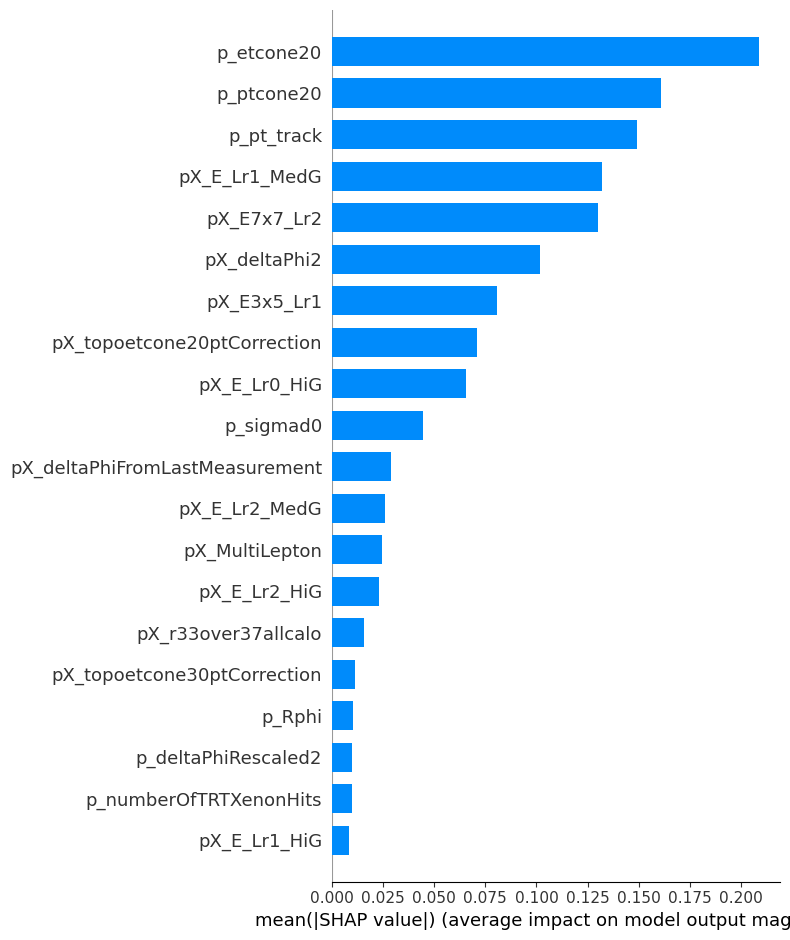

In [48]:

print("=== Phase 2.6: Ultra-Fast SHAP Value Ranking ===\n")

# 1. Take a subset of data to train the forest lightning fast
print("Sampling data to prevent memory overload...")
X_train_fast = X_train_final.sample(n=10000, random_state=42)
y_train_fast = y_train_kfold.loc[X_train_fast.index]

# 2. Train a restricted, lightweight Random Forest 
print("Training lightweight Random Forest... (Should take < 10 seconds)")
# max_depth=10 stops the trees from growing infinitely deep and eating your RAM
rf_model_fast = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=1)
rf_model_fast.fit(X_train_fast, y_train_fast)

# 3. Take a smaller sample for the SHAP explainer
print("Calculating exact SHAP values... (Should take ~30 seconds ⏳)")
X_shap_sample = X_train_fast.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(rf_model_fast)
shap_values = explainer.shap_values(X_shap_sample)

# 4. Rank and Display
shap_importance = np.abs(shap_values).mean(axis=0)
shap_ranking_df = pd.DataFrame({
    'Variable': X_train_final.columns,
    'Mean_SHAP_Impact_MeV': shap_importance
})
shap_ranking_df = shap_ranking_df.sort_values(by='Mean_SHAP_Impact_MeV', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 150)
print("\n✅ Variables Ranked by SHAP Values (Highest Impact to Lowest):")
display(shap_ranking_df.head(40)) # Only displaying the top 40 to keep it clean
pd.reset_option('display.max_rows')

# 5. The Beautiful Visual
print("\n📊 Generating the visual SHAP Summary Plot...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type="bar", max_display=20)

In [49]:
print(forward) 


['pX_maxEcell_x', 'pX_deltaEta1', 'p_sigmad0', 'pX_barys1', 'pX_maxEcell_time', 'p_deltaPhiRescaled2', 'pX_core57cellsEnergyCorrection', 'p_Eratio', 'p_etcone20', 'pX_deltaEta2', 'pX_f3core', 'pX_topoetcone30ptCorrection', 'pX_nCells_Lr1_HiG', 'p_d0', 'pX_MultiLepton', 'pX_deltaEta3', 'p_Rphi', 'pX_maxEcell_y', 'p_pt_track', 'pX_e2ts1']


In [ ]:
RFECV


In [50]:
shap_ranking_df = shap_ranking_df[:20]
perm_ranking_df = perm_ranking_df[:20]
tree_ranking_df = tree_ranking_df[:20]

In [51]:
print(shap_ranking_df)
print(perm_ranking_df)
print(tree_ranking_df)

                          Variable  Mean_SHAP_Impact_MeV
0                       p_etcone20              0.208565
1                       p_ptcone20              0.160924
2                       p_pt_track              0.149002
3                    pX_E_Lr1_MedG              0.132243
4                      pX_E7x7_Lr2              0.130033
5                     pX_deltaPhi2              0.101751
6                      pX_E3x5_Lr1              0.080645
7      pX_topoetcone20ptCorrection              0.071091
8                     pX_E_Lr0_HiG              0.065792
9                        p_sigmad0              0.044699
10  pX_deltaPhiFromLastMeasurement              0.028899
11                   pX_E_Lr2_MedG              0.026210
12                  pX_MultiLepton              0.024324
13                    pX_E_Lr2_HiG              0.023245
14             pX_r33over37allcalo              0.015933
15     pX_topoetcone30ptCorrection              0.011229
16                          p_R

In [53]:
import pandas as pd

print("=== Phase 6: Tie-Breaker Scoring for Disputed Variables ===\n")

# 1. Define the disputed variables 
# FIX: Use recursive_longway_2 instead of the class name RFECV
rfecv_list = recursive_longway_2['Variable'].tolist()
disputed_vars = list(set(forward).symmetric_difference(set(rfecv_list)))

print(f"🔍 Found {len(disputed_vars)} disputed variables to rank...\n")

# 2. Helper function to calculate the rank (or assign the 20 penalty)
def get_custom_rank(var, df, var_col='Variable'):
    """
    Looks for the variable in the Top 20 of the given DataFrame.
    Returns its 1-based rank if found, otherwise returns 20.
    """
    top_20_list = df[var_col].head(20).tolist()
    if var in top_20_list:
        return top_20_list.index(var) + 1
    return 20

# 3. Calculate the custom weight for each disputed variable
scoring_results = []

for var in disputed_vars:
    # Calculate 'a': Rank in RFECV if present, else Rank in Forward
    if var in rfecv_list:
        a = rfecv_list.index(var) + 1
        source = 'RFECV'
    else:
        a = forward.index(var) + 1
        source = 'Forward'
        
    # Calculate b, c, d using your exact DataFrames
    b = get_custom_rank(var, shap_ranking_df)
    c = get_custom_rank(var, tree_ranking_df)
    d = get_custom_rank(var, perm_ranking_df)
    
    # The Custom Formula
    weight = (2 * a) + b + c + d
    
    scoring_results.append({
        'Variable': var,
        'Source': source,
        'Rank_A (Wrap)': a,
        'Rank_B (SHAP)': b,
        'Rank_C (Tree)': c,
        'Rank_D (Perm)': d,
        'Final_Weight': weight
    })

# 4. Create the DataFrame and sort from lowest weight (best) to highest
disputed_ranking_df = pd.DataFrame(scoring_results)
disputed_ranking_df = disputed_ranking_df.sort_values(by='Final_Weight', ascending=True).reset_index(drop=True)

# 5. Display the results
print("⚖️ Disputed Variables Ranked by Custom Penalty Score (Lowest = Best):")
display(disputed_ranking_df)

=== Phase 6: Tie-Breaker Scoring for Disputed Variables ===

🔍 Found 26 disputed variables to rank...

⚖️ Disputed Variables Ranked by Custom Penalty Score (Lowest = Best):


,Variable,Source,Rank_A (Wrap),Rank_B (SHAP),Rank_C (Tree),Rank_D (Perm),Final_Weight
0,pX_E_Lr1_MedG,RFECV,3,4,4,8,22
1,p_ptcone20,RFECV,4,2,3,9,22
2,pX_E7x7_Lr2,RFECV,7,5,6,1,26
3,pX_deltaPhi2,RFECV,5,6,5,7,28
4,pX_topoetcone20ptCorrection,RFECV,6,8,7,6,33
5,pX_E3x5_Lr1,RFECV,8,7,8,4,35
6,pX_E_Lr0_HiG,RFECV,10,9,9,5,43
7,pX_deltaPhiFromLastMeasurement,RFECV,12,11,12,13,60
8,pX_deltaEta1,Forward,2,20,20,17,61
9,pX_E_Lr2_MedG,RFECV,9,12,11,20,61


In [54]:
print("=== Phase 7: Building the Ultimate Top 20 Roster ===\n")

# 1. Start with the undisputed MVPs (convert the set to a list)
final_top_20 = list(ultimate_mvps)
print(f"Starting with {len(final_top_20)} Undisputed MVPs.")

# 2. Calculate how many draft picks we still need
spots_remaining = 20 - len(final_top_20)
print(f"We need {spots_remaining} more variables to complete the team of 20.\n")

# 3. Draft the best disputed variables based on our custom penalty score
if spots_remaining > 0:
    # Grab the top 'N' names from your tie-breaker dataframe
    top_disputed = disputed_ranking_df['Variable'].head(spots_remaining).tolist()
    
    print("Drafting the following tie-breaker winners:")
    for var in top_disputed:
        # Get their score just to show why they won
        score = disputed_ranking_df.loc[disputed_ranking_df['Variable'] == var, 'Final_Weight'].values[0]
        print(f" + {var} (Score: {score})")
        
    # Add them to our final roster using .extend() to merge the lists
    final_top_20.extend(top_disputed)

# 4. Display the Final Official Top 20 List
print(f"\n✅ The Final, Officially Locked Top {len(final_top_20)} Variables:")
for i, var in enumerate(final_top_20, start=1):
    print(f" {i}. {var}")

# 5. Lock in the perfect datasets for the final XGBoost Evaluation
X_train_perfect = X_train_final[final_top_20]
X_test_perfect = X_test_final[final_top_20]
print("\n🔒 X_train_perfect and X_test_perfect are now locked to these 20 columns!")

=== Phase 7: Building the Ultimate Top 20 Roster ===

Starting with 7 Undisputed MVPs.
We need 13 more variables to complete the team of 20.

Drafting the following tie-breaker winners:
 + pX_E_Lr1_MedG (Score: 22)
 + p_ptcone20 (Score: 22)
 + pX_E7x7_Lr2 (Score: 26)
 + pX_deltaPhi2 (Score: 28)
 + pX_topoetcone20ptCorrection (Score: 33)
 + pX_E3x5_Lr1 (Score: 35)
 + pX_E_Lr0_HiG (Score: 43)
 + pX_deltaPhiFromLastMeasurement (Score: 60)
 + pX_deltaEta1 (Score: 61)
 + pX_E_Lr2_MedG (Score: 61)
 + pX_maxEcell_x (Score: 62)
 + pX_E_Lr2_HiG (Score: 65)
 + pX_barys1 (Score: 68)

✅ The Final, Officially Locked Top 20 Variables:
 1. p_sigmad0
 2. p_deltaPhiRescaled2
 3. p_d0
 4. p_pt_track
 5. p_etcone20
 6. pX_MultiLepton
 7. pX_topoetcone30ptCorrection
 8. pX_E_Lr1_MedG
 9. p_ptcone20
 10. pX_E7x7_Lr2
 11. pX_deltaPhi2
 12. pX_topoetcone20ptCorrection
 13. pX_E3x5_Lr1
 14. pX_E_Lr0_HiG
 15. pX_deltaPhiFromLastMeasurement
 16. pX_deltaEta1
 17. pX_E_Lr2_MedG
 18. pX_maxEcell_x
 19. pX_E_Lr2_H

=== Setting up LightGBM (Minimizing Relative Error via Sample Weights) ===

🚀 Training LightGBM on 5 Folds (Optimizing for RelMAD via Weights)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5066
[LightGBM] [Info] Number of data points in the train set: 144000, number of used features: 20
[LightGBM] [Info] Start training from score 0.134871


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 1 | MAE: 33442.5 MeV | RelMAD: 82.93%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5065
[LightGBM] [Info] Number of data points in the train set: 144000, number of used features: 20
[LightGBM] [Info] Start training from score 8.441922


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 2 | MAE: 31956.0 MeV | RelMAD: 79.12%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5065
[LightGBM] [Info] Number of data points in the train set: 144000, number of used features: 20
[LightGBM] [Info] Start training from score 0.741781


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 3 | MAE: 32466.1 MeV | RelMAD: 81.37%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001504 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5067
[LightGBM] [Info] Number of data points in the train set: 144000, number of used features: 20
[LightGBM] [Info] Start training from score 0.191546


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   Fold 4 | MAE: 32245.8 MeV | RelMAD: 80.82%
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5066
[LightGBM] [Info] Number of data points in the train set: 144000, number of used features: 20
[LightGBM] [Info] Start training from score 0.130319
   Fold 5 | MAE: 32450.7 MeV | RelMAD: 81.48%

✅ Cross-Validation Complete!
----------------------------------------
Average MAE:    32512.2 MeV
Average RelMAD: 81.14% (Typical relative error)
----------------------------------------



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_7743/3567003477.py:88: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'k--', lw=2, color='red')


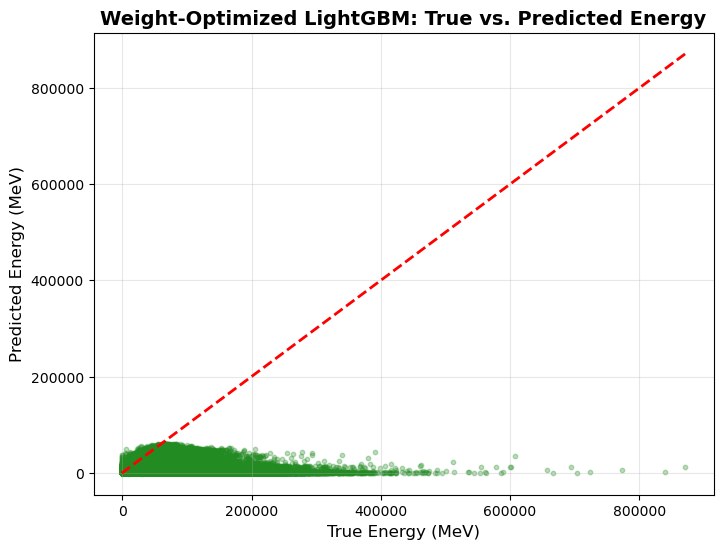

In [64]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

print("=== Setting up LightGBM (Using Pre-Logged Targets from Phase 2) ===\n")

# 1. Extract the final 20 features from your K-Fold training set
final_20_features = disputed_ranking_df['Variable'].head(20).tolist()
X = X_train_kfold[final_20_features].values

# 2. Extract the target (This is ALREADY in log-space thanks to your Phase 2 code!)
y_logged = y_train_kfold.values

# 3. Configure the K-Fold Splitter
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 4. Initialize LightGBM Regressor
# We use the default MSE objective here, which natively minimizes RelMAD because the data is logged
lgbm_model = lgb.LGBMRegressor(
    n_estimators=500,        
    learning_rate=0.05,      
    num_leaves=31,           
    max_depth=-1,            
    random_state=42,
    n_jobs=-1                
)

# Arrays to store out-of-fold predictions
oof_predictions_mev = np.zeros(len(X))
mae_scores = []
relmad_scores = []

print(f"🚀 Training LightGBM on {n_splits} Folds...")

# 5. The K-Fold Training Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    # Split the data
    X_train_fold, y_train_fold = X[train_idx], y_logged[train_idx]
    X_val_fold, y_val_fold = X[val_idx], y_logged[val_idx]
    
    # Train the model on the LOGGED data
    lgbm_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    # Predict on the validation fold (The output is natively in Log space)
    val_preds_logged = lgbm_model.predict(X_val_fold)
    
    # 💥 Reverse the log using np.exp() to get actual MeV for our metrics
    val_preds_mev = np.exp(val_preds_logged)
    y_val_mev = np.exp(y_val_fold)
    
    # Save the predictions for out-of-fold analysis
    oof_predictions_mev[val_idx] = val_preds_mev
    
    # Calculate fold metrics
    fold_mae = mean_absolute_error(y_val_mev, val_preds_mev)
    
    # Calculate RelMAD: Median of |(E_pred - E_true) / E_true|
    relative_errors = np.abs((val_preds_mev - y_val_mev) / y_val_mev)
    fold_relmad = np.median(relative_errors) * 100 # Converted to percentage
    
    mae_scores.append(fold_mae)
    relmad_scores.append(fold_relmad)
    
    print(f"   Fold {fold + 1} | MAE: {fold_mae:.1f} MeV | RelMAD: {fold_relmad:.2f}%")

# 6. Final Results
print("\n✅ Cross-Validation Complete!")
print(f"----------------------------------------")
print(f"Average MAE:    {np.mean(mae_scores):.1f} MeV")
print(f"Average RelMAD: {np.mean(relmad_scores):.2f}%")
print(f"----------------------------------------\n")

# 7. Visualizing True vs. Predicted for the Out-Of-Fold data
true_energy_mev = np.exp(y_logged)

plt.figure(figsize=(8, 6))
plt.scatter(true_energy_mev, oof_predictions_mev, alpha=0.3, color='purple', s=10)
plt.plot([true_energy_mev.min(), true_energy_mev.max()], [true_energy_mev.min(), true_energy_mev.max()], 'k--', lw=2, color='red')
plt.title('Log-Optimized LightGBM: True vs. Predicted Energy', fontsize=14, fontweight='bold')
plt.xlabel('True Energy (MeV)', fontsize=12)
plt.ylabel('Predicted Energy (MeV)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

=== Evaluating Log-Optimized LightGBM on the Locked Test Set ===

Generating predictions on unseen data...

🏆 FINAL TEST SET PERFORMANCE METRICS:
----------------------------------------
MAE (Mean Absolute Error): 8464.3 MeV
RMSE (Root Mean Squared Error): 18290.0 MeV
RelMAD (Median Relative Error): 7.14%
R-squared (R²): 0.8931
----------------------------------------



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_7743/2161215084.py:48: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red', label='Perfect Prediction')


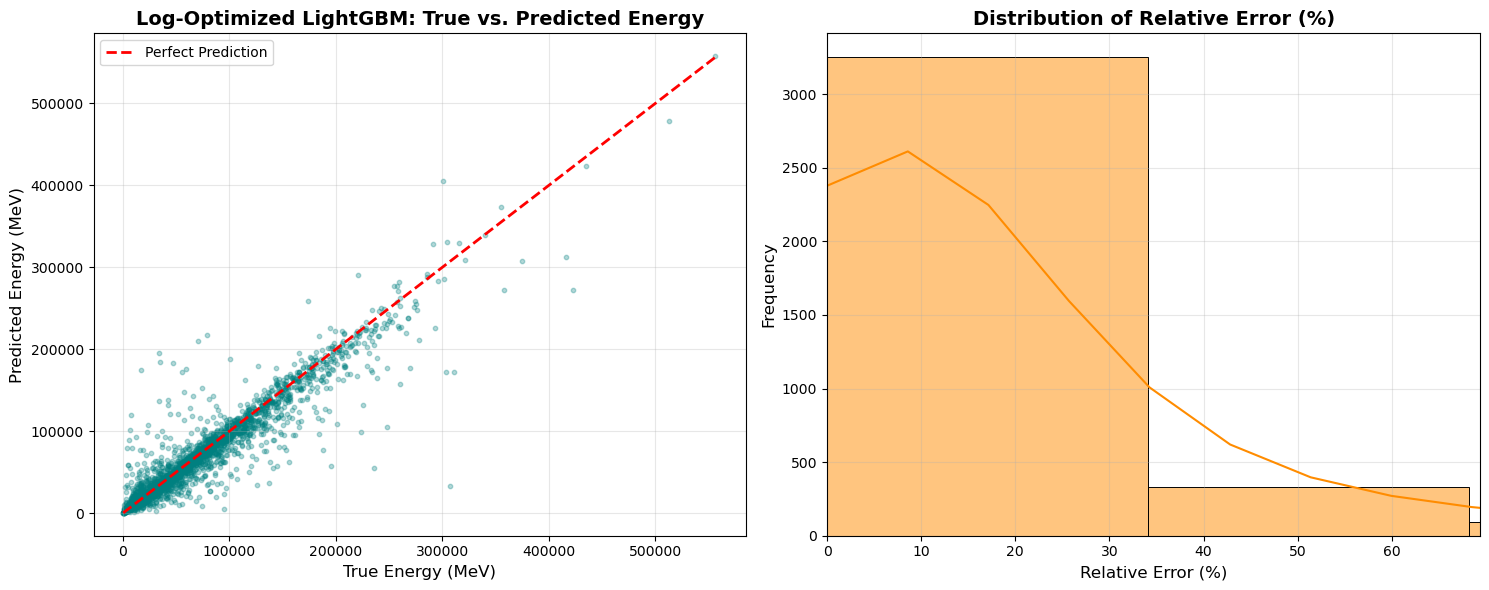

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Evaluating Log-Optimized LightGBM on the Locked Test Set ===\n")

# 1. Extract the features from X_test 
X_test_final = X_test[final_20_features].values

# 2. Extract the target (already in log-space from Phase 2)
y_test_logged = y_test.values

# 3. Generate Predictions (Output will be in log-space)
print("Generating predictions on unseen data...")
test_preds_logged = lgbm_model.predict(X_test_final)

# 4. 💥 Reverse the log transform so we can calculate metrics in real MeV!
y_test_mev = np.exp(y_test_logged)
test_preds_mev = np.exp(test_preds_logged)

# 5. Calculate Regression Metrics
mae = mean_absolute_error(y_test_mev, test_preds_mev)
rmse = np.sqrt(mean_squared_error(y_test_mev, test_preds_mev))
r2 = r2_score(y_test_mev, test_preds_mev)

# Calculate RelMAD: Median of |(E_pred - E_true) / E_true|
relative_errors = np.abs((test_preds_mev - y_test_mev) / y_test_mev)
relmad = np.median(relative_errors) * 100

print(f"\n🏆 FINAL TEST SET PERFORMANCE METRICS:")
print(f"----------------------------------------")
print(f"MAE (Mean Absolute Error): {mae:.1f} MeV")
print(f"RMSE (Root Mean Squared Error): {rmse:.1f} MeV")
print(f"RelMAD (Median Relative Error): {relmad:.2f}%")
print(f"R-squared (R²): {r2:.4f}")
print(f"----------------------------------------\n")

# 6. Generate Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: True vs Predicted Energy ---
axes[0].scatter(y_test_mev, test_preds_mev, alpha=0.3, color='teal', s=10)
# Draw the perfect 1:1 prediction line
min_val = min(y_test_mev.min(), test_preds_mev.min())
max_val = max(y_test_mev.max(), test_preds_mev.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red', label='Perfect Prediction')

axes[0].set_title('Log-Optimized LightGBM: True vs. Predicted Energy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('True Energy (MeV)', fontsize=12)
axes[0].set_ylabel('Predicted Energy (MeV)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Relative Error Distribution ---
# For physics, plotting the distribution of the relative error is very insightful
sns.histplot(relative_errors * 100, bins=50, kde=True, color='darkorange', ax=axes[1])
# Limit the x-axis so massive outliers don't squash the graph
axes[1].set_xlim([0, np.percentile(relative_errors * 100, 95)]) 

axes[1].set_title('Distribution of Relative Error (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Error (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import KFold

print("=== Setting up Optuna Hyperparameter Search for LightGBM ===\n")

# 1. Extract the Data (Already correctly logged from Phase 2)
final_20_features = disputed_ranking_df['Variable'].head(20).tolist()
X = X_train_kfold[final_20_features].values
y_logged = y_train_kfold.values

# 2. Define the Optuna Objective Function
def objective(trial):
    # --- Define the Hyperparameters to Search ---
    param = {
        'objective': 'regression',
        'metric': 'mae', # Internal metric for LightGBM early stopping
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': 800, # Give it plenty of trees, early stopping will cut it off if needed
        
        # The parameters Optuna gets to play with:
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        
        'random_state': 42,
        'n_jobs': -1
    }
    
    # --- 5-Fold Cross Validation ---
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_relmad_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, y_train_fold = X[train_idx], y_logged[train_idx]
        X_val_fold, y_val_fold = X[val_idx], y_logged[val_idx]
        
        # Initialize and train the model for this fold
        model = lgb.LGBMRegressor(**param)
        model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )
        
        # Predict and calculate RelMAD
        val_preds_logged = model.predict(X_val_fold)
        
        # Reverse the log to get actual MeV
        val_preds_mev = np.exp(val_preds_logged)
        y_val_mev = np.exp(y_val_fold)
        
        # Calculate the actual RelMAD for this fold
        relative_errors = np.abs((val_preds_mev - y_val_mev) / y_val_mev)
        relmad = np.median(relative_errors) * 100
        
        fold_relmad_scores.append(relmad)
        
    # Optuna's goal is to minimize this average RelMAD score
    return np.mean(fold_relmad_scores)

# 3. Create the Study and Run It
print("🚀 Starting the tuning process... (Running 20 trials)")
# We use direction='minimize' because we want the lowest possible error
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) 

# 4. Print the Winning Results
print("\n🏆 Hyperparameter Search Complete!")
print(f"Best Cross-Validated RelMAD: {study.best_value:.2f}%")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f" - {key}: {value}")

[I 2026-05-17 00:14:02,986] A new study created in memory with name: no-name-69cb27bf-3280-46f5-911e-7d12998b78e2


=== Setting up Optuna Hyperparameter Search for LightGBM ===

🚀 Starting the tuning process... (Running 20 trials)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-05-17 00:15:10,522] Trial 0


🏆 Hyperparameter Search Complete!
Best Cross-Validated RelMAD: 6.29%
Best Parameters:
 - learning_rate: 0.009258835728379195
 - num_leaves: 125
 - max_depth: 11
 - min_child_samples: 40
 - subsample: 0.7883795483199895
 - colsample_bytree: 0.6263334670380638


=== Building and Testing the Champion LightGBM Model ===

Training the Champion Model...
Generating final predictions on the locked vault data...

🏆 CHAMPION TEST SET PERFORMANCE:
----------------------------------------
MAE (Absolute Error): 8210.3 MeV
RMSE:                 18069.8 MeV
RelMAD:               6.38%
R-squared:            0.8957
----------------------------------------



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/f9/z5t5v20d5s3gk1bx790p3rrr0000gq/T/ipykernel_7743/3226479110.py:72: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red', label='Perfect Prediction')


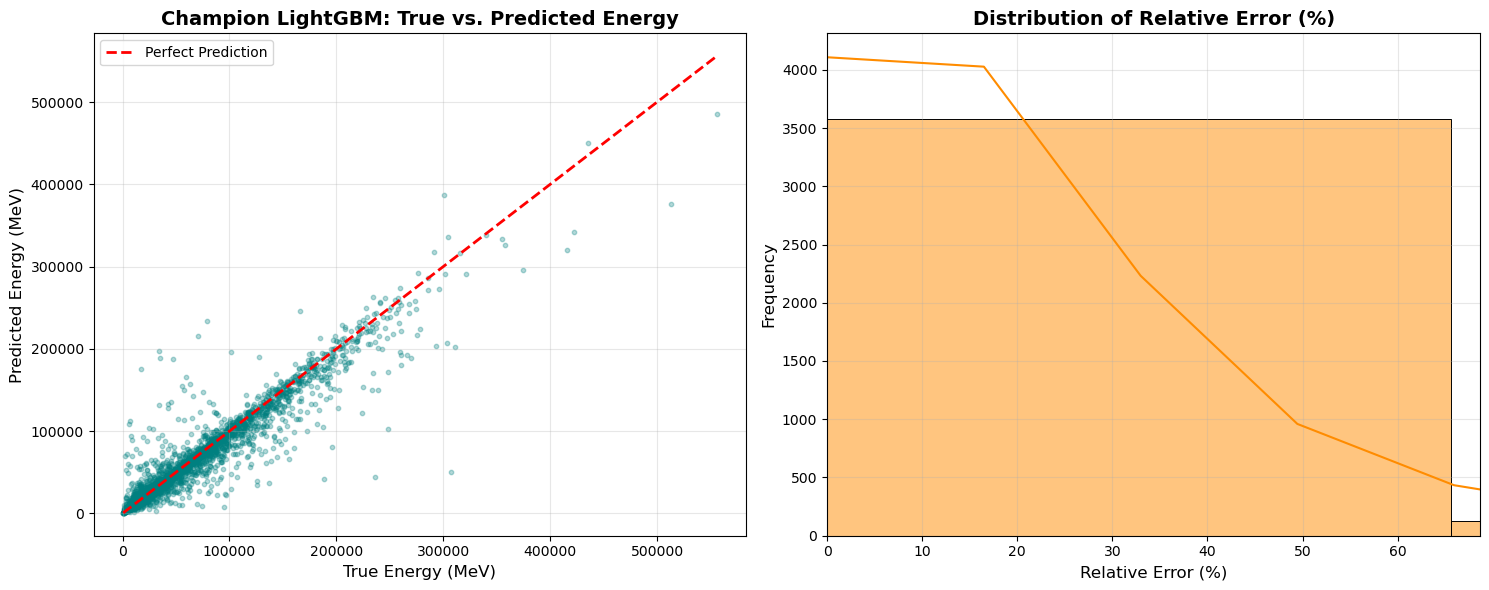

In [69]:
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=== Building and Testing the Champion LightGBM Model ===\n")

# 1. Grab the winning parameters automatically from Optuna
best_params = study.best_params
best_params['objective'] = 'regression'
best_params['metric'] = 'mae'
best_params['verbosity'] = -1
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['n_estimators'] = 1000 # High number, early stopping will cut it off

# 2. Prepare the Training Data
final_20_features = disputed_ranking_df['Variable'].head(20).tolist()
X_full_train = X_train_kfold[final_20_features].values
y_full_train_logged = y_train_kfold.values

# Create a small internal validation set just for Early Stopping
X_t, X_v, y_t, y_v = train_test_split(X_full_train, y_full_train_logged, test_size=0.1, random_state=42)

# 3. Train the Champion Model
print("Training the Champion Model...")
champion_model = lgb.LGBMRegressor(**best_params)
champion_model.fit(
    X_t, y_t,
    eval_set=[(X_v, y_v)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# 4. Prepare the Locked Test Data
X_test_final = X_test[final_20_features].values
y_test_logged = y_test.values

# 5. Generate Predictions on the Unseen Test Data!
print("Generating final predictions on the locked vault data...")
test_preds_logged = champion_model.predict(X_test_final)

# 💥 Reverse the log transform to get actual MeV!
y_test_mev = np.exp(y_test_logged)
test_preds_mev = np.exp(test_preds_logged)

# 6. Calculate Final Metrics
mae = mean_absolute_error(y_test_mev, test_preds_mev)
rmse = np.sqrt(mean_squared_error(y_test_mev, test_preds_mev))
r2 = r2_score(y_test_mev, test_preds_mev)

relative_errors = np.abs((test_preds_mev - y_test_mev) / y_test_mev)
relmad = np.median(relative_errors) * 100

print(f"\n🏆 CHAMPION TEST SET PERFORMANCE:")
print(f"----------------------------------------")
print(f"MAE (Absolute Error): {mae:.1f} MeV")
print(f"RMSE:                 {rmse:.1f} MeV")
print(f"RelMAD:               {relmad:.2f}%")
print(f"R-squared:            {r2:.4f}")
print(f"----------------------------------------\n")

# 7. Generate Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: True vs Predicted Energy ---
axes[0].scatter(y_test_mev, test_preds_mev, alpha=0.3, color='teal', s=10)
min_val = min(y_test_mev.min(), test_preds_mev.min())
max_val = max(y_test_mev.max(), test_preds_mev.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red', label='Perfect Prediction')

axes[0].set_title('Champion LightGBM: True vs. Predicted Energy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('True Energy (MeV)', fontsize=12)
axes[0].set_ylabel('Predicted Energy (MeV)', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Relative Error Distribution ---
sns.histplot(relative_errors * 100, bins=50, kde=True, color='darkorange', ax=axes[1])
axes[1].set_xlim([0, np.percentile(relative_errors * 100, 95)]) 

axes[1].set_title('Distribution of Relative Error (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relative Error (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
import numpy as np

print("=== Generating Final Submission Files for Task 2 (Regression) ===\n")

# 1. Load the Blind Test Dataset
# Change '.h5' to '.csv' if you downloaded the csv version instead!
blind_data_file = 'AppML_InitialProject_test_regression.h5'
print(f"Loading blind test data from: {blind_data_file}")
blind_test_df = pd.read_hdf(blind_data_file)

# 2. Extract ONLY the 20 features we used for the model
X_blind_test = blind_test_df[final_20_features].values

# 3. Generate Predictions using the Champion Model (Output is in Log-Space)
print("Running champion model on blind data...")
blind_preds_logged = champion_model.predict(X_blind_test)

# 4. Reverse the log transform to get the final predictions in MeV
blind_preds_mev = np.exp(blind_preds_logged)

# ==========================================
# FILE 1: THE PREDICTIONS FILE
# ==========================================
# Create a DataFrame matching the requested format: Index, Energy(MeV)
submission_df = pd.DataFrame({
    'Index': range(len(blind_preds_mev)), 
    'Estimate': blind_preds_mev
})

# Save to CSV without headers or index so it looks exactly like: "0, 45012.34"
predictions_filename = 'predictions_task2_regression.csv'
submission_df.to_csv(predictions_filename, header=False, index=False)

print(f"\n✅ Created Predictions File: {predictions_filename}")
print(f"   (First 3 rows preview):")
print(f"   0, {blind_preds_mev[0]:.6f}")
print(f"   1, {blind_preds_mev[1]:.6f}")
print(f"   2, {blind_preds_mev[2]:.6f}\n")

# ==========================================
# FILE 2: THE VARIABLES FILE
# ==========================================
# A simple text file listing your 20 chosen variables
variables_filename = 'variables_task2_regression.txt'

with open(variables_filename, 'w') as f:
    for var in final_20_features:
        f.write(f"{var}\n")

print(f"✅ Created Variables File:   {variables_filename}")
print(f"   (Contains exactly {len(final_20_features)} variables)")

print("\n🎉 CONGRATULATIONS! Your submission files are ready to hand in!")

=== Generating Final Submission Files for Task 2 (Regression) ===

Loading blind test data from: AppML_InitialProject_test_regression.h5
Running champion model on blind data...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



✅ Created Predictions File: predictions_task2_regression.csv
   (First 3 rows preview):
   0, 8446.542112
   1, 95195.674933
   2, 91352.217063

✅ Created Variables File:   variables_task2_regression.txt
   (Contains exactly 20 variables)

🎉 CONGRATULATIONS! Your submission files are ready to hand in!
